In [1]:
import re
import datetime
import pathlib
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
VERSION = datetime.datetime.now().strftime("%y%m%d")
print(f"Execute Date: {VERSION}")

Execute Date: 260324


## Parameters for papermill

In [3]:
foldseek_result_tsv = pathlib.Path("../test/oryza_sativa_test_100genes_202603/foldseek_output_human_proteome_v6_os_100_genes_9606.tsv")
query_uniprot_idmapping_tsv = pathlib.Path("../test/oryza_sativa_test_100genes_202603/os_100_genes_idmapping_all.tsv")
water_result_dir_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/result_water")
needle_result_dir_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/result_needle")
query_gene_list_tsv_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/oryza_sativa_random_100genes_list.tsv")
togoid_convert_tsv_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/foldseek_target_species_togoid_convert.tsv")

In [4]:
# Parameters
foldseek_result_tsv = "/tmp/8hyavzvb/stg89280440-68a9-4a51-a344-d72ba85692d3/foldseek_os_random_9606.tsv"
query_uniprot_idmapping_tsv = "/tmp/8hyavzvb/stg7961e022-8d20-4797-8a28-69195a082e39/gm_100_genes_idmapping_all.tsv"
water_result_dir_path = "/tmp/8hyavzvb/stged4f8918-047d-4311-a19d-baccc4325d1c/result_water"
needle_result_dir_path = "/tmp/8hyavzvb/stg160c6c8b-406d-4ea3-a6db-7f63ea01034e/result_needle"
query_gene_list_tsv_path = "/tmp/8hyavzvb/stg8300bdf3-d11c-4ad0-a3ce-86f277baa6ba/glycine_max_random_100genes_list.tsv"
togoid_convert_tsv_path = "/tmp/8hyavzvb/stg0b233b3f-d15c-41e4-9670-03fe8498ce48/foldseek_hit_species_togoid_convert.tsv"


&nbsp;

&nbsp;

&nbsp;

## (1) Foldseek (Structural Alignment) Result

- Foldseek version: [10-941cd33](https://github.com/steineggerlab/foldseek/releases/tag/10-941cd33)
- About Column name: [foldseek GitHub page](https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search)
- In this workflow, foldseek alignment type is `TM-align` (default). So, `e-value` column means `(qTMscore+tTMscore) / 2`
- More details: [TM-align Alignment mode](https://github.com/steineggerlab/foldseek?tab=readme-ov-file#alignment-mode)

&nbsp;

### About Hit Pairs

- In this analysis workflow, the results are output with multiple hits remaining for a single query UniProt ID (protein structure).

&nbsp;

In [5]:
foldseek_result_df = pl.read_csv(
    foldseek_result_tsv,
    separator='\t'
).with_columns(
    (pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession")), # "?" means non-greedy
    (pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit"))
)

foldseek_result = pl.read_csv(
    query_uniprot_idmapping_tsv, # query idmapping
    separator='\t'
).join(
    foldseek_result_df,
    on="UniProt Accession",
    how="inner",
    coalesce=True
)

display(foldseek_result)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str
"""GLYMA_11G222400""","""K7LRL6""","""Q7Z4W1""",0.8953,0.991,4,26.6,0.266,68,15,268,277,1,244,244,255,0.917,1.0,0.8108,0.8475,0.959,0.9628,1.424,"""RGARWSLNGMTALVTGGTRGIGHAIVNDLA…","""ME--LFLAGRRVLVTGAGKGIGRGTVQALH…",175,"""0.461,0.530,0.588,0.716,0.733,…"
"""GLYMA_11G222400""","""K7LRL6""","""Q8N4T8""",0.8873,0.988,5,27.4,0.274,68,22,269,277,1,237,237,248,0.895,1.0,0.8018,0.8275,0.9632,0.9672,1.339,"""NGMTALVTGGTRGIGHAIVNDLAAFGAAVH…","""MDKVCAVFGGSRGIGRAVAQLMARKGYRLA…",169,"""0.369,0.531,0.614,0.722,0.778,…"
"""GLYMA_11G222400""","""K7LRL6""","""Q92506""",0.8798,0.992,6,27.3,0.273,71,16,267,277,4,261,261,260,0.91,0.989,0.8078,0.8629,0.9139,0.9492,1.776,"""GARWSLNGMTALVTGGTRGIGHAIVNDLAA…","""QLQNRLRSALALVTGAGSGIGRAVSVRLAG…",179,"""0.300,0.268,0.338,0.345,0.778,…"
"""GLYMA_11G222400""","""K7LRL6""","""Q9BTZ2""",0.8758,0.994,2,32.8,0.328,85,11,268,277,20,277,278,259,0.931,0.928,0.8457,0.8854,0.8823,0.9523,1.879,"""SSINRGARWSLNGMTALVTGGTRGIGHAIV…","""ASSGMTRRDPLANKVALVTASTDGIGFAIA…",172,"""0.458,0.545,0.500,0.406,0.526,…"
"""GLYMA_11G222400""","""K7LRL6""","""Q9BUT1""",0.8746,0.988,7,25.6,0.256,66,16,267,277,1,245,245,257,0.91,1.0,0.8031,0.8314,0.9364,0.9401,1.513,"""GARWSLNGMTALVTGGTRGIGHAIVNDLAA…","""M--GRLDGKVIILTAAAQGIGQAAALAFAR…",174,"""0.270,0.284,0.716,0.741,0.739,…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GLYMA_09G188500""","""A0A0R0IA95""","""Q9UHE8""",0.2859,0.082,19,4.8,0.048,10,166,316,317,130,324,339,207,0.476,0.575,0.4446,0.3104,0.294,0.5454,5.522,"""I--ISFI-NWL--TDC-----FGSEKYA-E…","""YLP--GVI-AAIV--QLHNGT--KYKKFP-…",129,"""0.270,0.314,0.278,0.262,0.344,…"
"""GLYMA_09G188500""","""A0A0R0IA95""","""O14495""",0.2693,0.063,22,4.2,0.042,15,62,287,317,19,282,311,355,0.713,0.849,0.411,0.2848,0.2891,0.365,6.174,"""LSALTEMKG--LKGCKVGKNCLGADGVLRV…","""SPAL-NNNPRR--------------S-GSK…",120,"""0.121,0.232,0.307,0.169,0.231,…"
"""GLYMA_09G188500""","""A0A0R0IA95""","""Q96DW6""",0.2411,0.045,17,1.9,0.019,5,34,278,317,175,303,304,260,0.773,0.424,0.4062,0.2517,0.2602,0.4944,5.855,"""P--WMARYVYGLIFLVANLLAWAARDELSS…","""RGLFSGLTATLLRDAPFSGIYLMFYNQTKN…",109,"""0.188,0.270,0.230,0.297,0.364,…"


&nbsp;

&nbsp;

## (2) Create Scatter Plot for all hits (Strucutural alignment identity vs LDDT)

- Identity in the results of the structural alignment is also output in the foldseek output.
- However, in this notebook, you can also select the results of the pairwise alignment of amino acid sequences (global alignment, local alignment).

&nbsp;

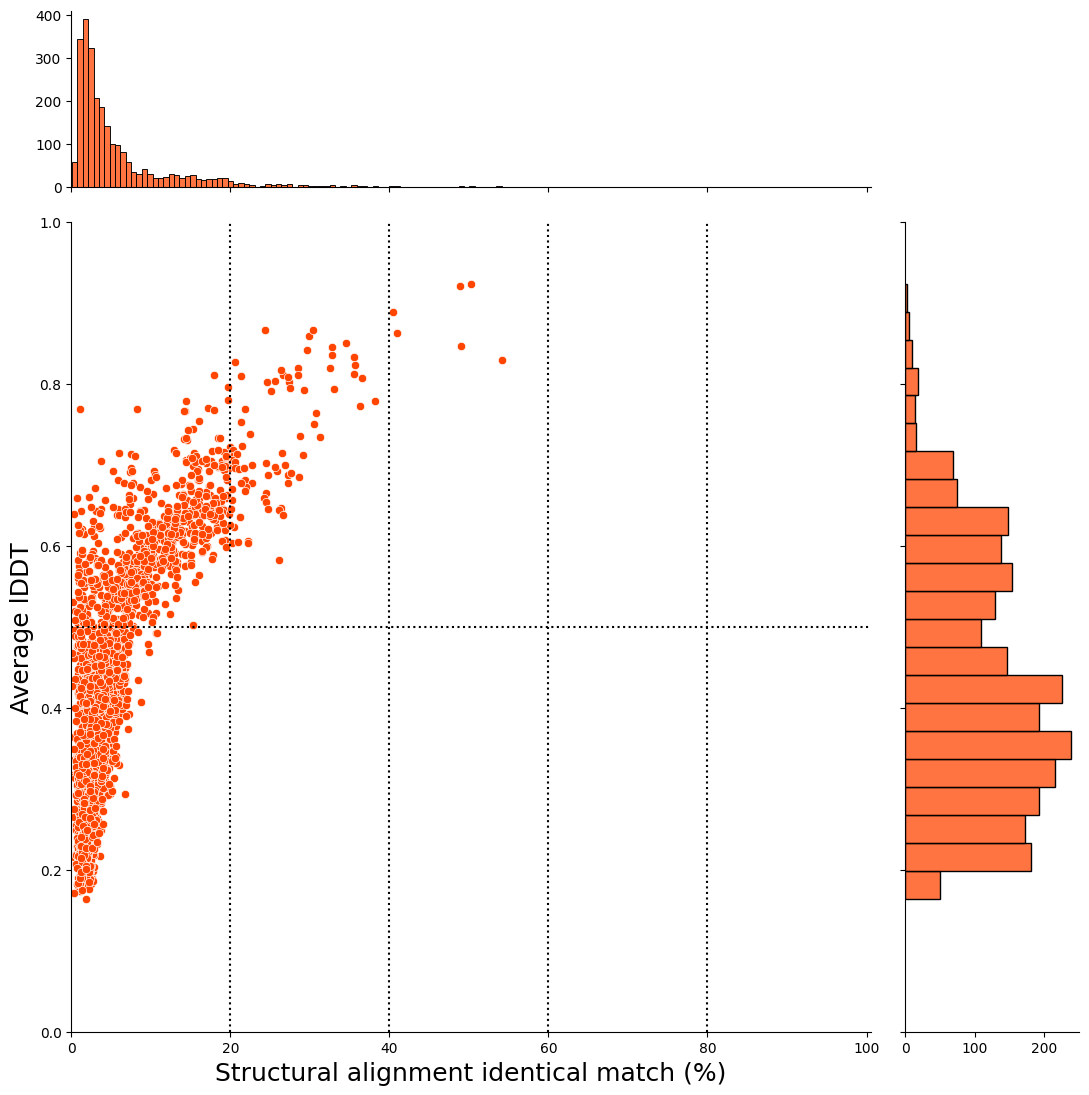

In [6]:
foldseek_filter_viz = foldseek_result.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz,
    x="pident", # structural alignment identical match from foldseek result
    y="lddt",
    color="orangered",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(0,100.5)
plt.ylim(0,1)
plt.xlabel("Structural alignment identical match (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

# Save as PNG
plt.savefig(
    "foldseek_result_pident_lddt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (3) Parse protein sequence pairwise alignment result (water and needle)

- package: EMBOSS:6.5.7--4
- Score Subsutitution Matrix: EBLOSUM30 (For considering remote similarity)
- Website: [EMBOSS](https://emboss.sourceforge.net/)
- needle document: [EMBOSS needle](https://emboss.sourceforge.net/apps/release/6.0/emboss/apps/needle.html)
- water document: [EMBOSS water](https://emboss.sourceforge.net/apps/cvs/emboss/apps/water.html)
- EMBL-EBI Webserver: [EMBOSS NEEDLE](https://www.ebi.ac.uk/jdispatcher/psa/emboss_needle)
- EMBL-EBI Webserver: [EMBOSS WATER](https://www.ebi.ac.uk/jdispatcher/psa/emboss_water)

- For pairs hit by Foldseek (structural alignment), we perform analysis on the sequence similarity observed upon alignment at the `protein sequence level`.
- In other words, it is performing an alignment again on the pair of sequences, not just the regions aligned by Foldseek.

&nbsp;

In [7]:
def parse_needle_water_result(file_path: str | pathlib.Path) -> dict:
    with open(file_path, "r", encoding="utf-8") as file:
        data = file.readlines()

    result = {
        "UniProt Accession": None,
        "foldseek hit": None,
        "Matrix": None,
        "Gap_penalty": None,
        "Extend_penalty": None,
        "Align_Length": None,
        "Identity": None,
        "Identity_percent": None,
        "Similarity": None,
        "Similarity_percent": None,
        "Gaps": None,
        "Gaps_percent": None,
        "Score": None,
        "Longest_Identity": None,
        "Longest_Similarity": None,
        "Shortest_Identity": None,
        "Shortest_Similarity": None,
    }

    for line in data:
        if line.startswith("# 1:"):
            result['UniProt Accession'] = line.split(":")[1].strip()
        elif line.startswith("# 2:"):
            result["foldseek hit"] = line.split(":")[1].strip()
        elif line.startswith("# Matrix:"):
            result["Matrix"] = line.split(":")[1].strip()
        elif line.startswith("# Gap_penalty:"):
            result["Gap_penalty"] = float(line.split(":")[1].strip())
        elif line.startswith("# Extend_penalty:"):
            result["Extend_penalty"] = float(line.split(":")[1].strip())
        elif line.startswith("# Length:"):
            result["Align_Length"] = int(line.split()[2])
        elif line.startswith("# Identity:"):
            result["Identity"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Identity_percent"] = float(m.group(1))
        elif line.startswith("# Similarity:"):
            result["Similarity"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Similarity_percent"] = float(m.group(1))
        elif line.startswith("# Gaps:"):
            result["Gaps"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Gaps_percent"] = float(m.group(1))
        elif line.startswith("# Score:"):
            result["Score"] = float(line.split()[2])
        elif line.startswith("# Longest_Identity"):
            result["Longest_Identity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Longest_Similarity"):
            result["Longest_Similarity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Shortest_Identity"):
            result["Shortest_Identity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Shortest_Similarity"):
            result["Shortest_Similarity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )

    return result

In [8]:
water_result_dir = pathlib.Path(water_result_dir_path)
needle_result_dir = pathlib.Path(needle_result_dir_path)

# Initialize empty lists to store DataFrames
water_dfs = []
needle_dfs = []

# Collect all water results
for result_file in water_result_dir.glob("*_align.water"):
    parsed_data = parse_needle_water_result(result_file)
    water_dfs.append(pl.DataFrame([parsed_data]))

# Collect all needle results    
for result_file in needle_result_dir.glob("*_align.needle"):
    parsed_data = parse_needle_water_result(result_file)
    needle_dfs.append(pl.DataFrame([parsed_data]))

# Combine all results and sort only if there are results
water_result = (pl.concat(water_dfs, how='vertical')
                .sort(["UniProt Accession", "foldseek hit"]) 
                if water_dfs else pl.DataFrame()).with_columns(
                    pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession"), # add removing AF- prefix
                    pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit") # add removing AF- prefix
                )

needle_result = (pl.concat(needle_dfs, how='vertical')
                 .sort(["UniProt Accession", "foldseek hit"])
                 if needle_dfs else pl.DataFrame()).with_columns(
                    pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession"), # add removing AF- prefix
                    pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit") # add removing AF- prefix
                )

display(water_result)
display(needle_result)

UniProt Accession,foldseek hit,Matrix,Gap_penalty,Extend_penalty,Align_Length,Identity,Identity_percent,Similarity,Similarity_percent,Gaps,Gaps_percent,Score,Longest_Identity,Longest_Similarity,Shortest_Identity,Shortest_Similarity
str,str,str,f64,f64,i64,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64
"""A0A0R0EI55""","""A2RU54""","""EBLOSUM30""",10.0,0.5,239,"""47/239""",19.7,"""81/239""",33.9,"""90/239""",37.7,205.5,31.54,54.36,17.22,29.67
"""A0A0R0EI55""","""A6NJ46""","""EBLOSUM30""",10.0,0.5,273,"""50/273""",18.3,"""95/273""",34.8,"""97/273""",35.5,195.5,28.41,53.98,18.87,35.85
"""A0A0R0EI55""","""A8MTQ0""","""EBLOSUM30""",10.0,0.5,237,"""46/237""",19.4,"""89/237""",37.6,"""77/237""",32.5,208.0,28.75,55.62,18.33,35.46
"""A0A0R0EI55""","""P09017""","""EBLOSUM30""",10.0,0.5,244,"""44/244""",18.0,"""80/244""",32.8,"""108/244""",44.3,204.5,32.35,58.82,16.67,30.3
"""A0A0R0EI55""","""P09067""","""EBLOSUM30""",10.0,0.5,239,"""43/239""",18.0,"""79/239""",33.1,"""100/239""",41.8,180.0,30.94,56.83,15.99,29.37
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""K7N154""","""O95257""","""EBLOSUM30""",10.0,0.5,163,"""31/163""",19.0,"""59/163""",36.2,"""55/163""",33.7,122.0,28.7,54.63,19.5,37.11
"""K7N154""","""P24522""","""EBLOSUM30""",10.0,0.5,154,"""33/154""",21.4,"""59/154""",38.3,"""58/154""",37.7,132.0,34.38,61.46,20.0,35.76
"""K7N154""","""P25398""","""EBLOSUM30""",10.0,0.5,118,"""44/118""",37.3,"""71/118""",60.2,"""6/118""",5.1,337.0,39.29,63.39,28.39,45.81


UniProt Accession,foldseek hit,Matrix,Gap_penalty,Extend_penalty,Align_Length,Identity,Identity_percent,Similarity,Similarity_percent,Gaps,Gaps_percent,Score,Longest_Identity,Longest_Similarity,Shortest_Identity,Shortest_Similarity
str,str,str,f64,f64,i64,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64
"""A0A0R0EI55""","""A2RU54""","""EBLOSUM30""",10.0,0.5,327,"""47/327""",14.4,"""83/327""",25.4,"""169/327""",51.7,198.0,29.75,52.53,17.22,30.4
"""A0A0R0EI55""","""A6NJ46""","""EBLOSUM30""",10.0,0.5,299,"""50/299""",16.7,"""95/299""",31.8,"""121/299""",40.5,193.5,28.09,53.37,18.87,35.85
"""A0A0R0EI55""","""A8MTQ0""","""EBLOSUM30""",10.0,0.5,294,"""47/294""",16.0,"""92/294""",31.3,"""125/294""",42.5,207.0,27.81,54.44,18.73,36.65
"""A0A0R0EI55""","""P09017""","""EBLOSUM30""",10.0,0.5,336,"""44/336""",13.1,"""80/336""",23.8,"""196/336""",58.3,202.5,31.43,57.14,16.67,30.3
"""A0A0R0EI55""","""P09067""","""EBLOSUM30""",10.0,0.5,321,"""45/321""",14.0,"""85/321""",26.5,"""161/321""",50.2,173.5,28.12,53.12,16.73,31.6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""K7N154""","""O95257""","""EBLOSUM30""",10.0,0.5,195,"""32/195""",16.4,"""65/195""",33.3,"""76/195""",39.0,115.5,26.89,54.62,20.13,40.88
"""K7N154""","""P24522""","""EBLOSUM30""",10.0,0.5,216,"""35/216""",16.2,"""67/216""",31.0,"""112/216""",51.9,124.0,33.65,64.42,21.21,40.61
"""K7N154""","""P25398""","""EBLOSUM30""",10.0,0.5,175,"""45/175""",25.7,"""71/175""",40.6,"""63/175""",36.0,330.5,40.18,63.39,29.03,45.81


In [9]:
alignment_result = water_result.join(
    needle_result,
    on=["UniProt Accession", "foldseek hit"],
    how="inner",
    coalesce=True,
    suffix="_needle"
).rename(
    {
        "Align_Length": "Align_Length_water",
        "Identity": "Identity_water",
        "Identity_percent": "Identity_percent_water",
        "Similarity": "Similarity_water",
        "Similarity_percent": "Similarity_percent_water",
        "Gaps": "Gaps_water",
        "Gaps_percent": "Gaps_percent_water",
        "Longest_Identity": "Longest_Identity_water",
        "Longest_Similarity": "Longest_Similarity_water",
        "Shortest_Identity": "Shortest_Identity_water",
        "Shortest_Similarity": "Shortest_Similarity_water",
        "Score": "Score_water"
    }
).select(
    [
        "UniProt Accession",
        "foldseek hit",
        "Align_Length_water",
        "Align_Length_needle",
        "Identity_water",
        "Identity_needle",
        "Identity_percent_water",
        "Identity_percent_needle",
        "Similarity_percent_water",
        "Similarity_percent_needle",
        "Gaps_water",
        "Gaps_needle",
        "Gaps_percent_water",
        "Gaps_percent_needle",
        "Shortest_Identity_water",
        "Shortest_Identity_needle",
        "Longest_Identity_water",
        "Longest_Identity_needle",
        "Shortest_Similarity_water",
        "Shortest_Similarity_needle",
        "Longest_Similarity_water",
        "Longest_Similarity_needle",
        "Score_water",
        "Score_needle",
        "Gap_penalty",
        "Extend_penalty",
        "Matrix"
    ]
)

display(alignment_result)

UniProt Accession,foldseek hit,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""A0A0R0EI55""","""A2RU54""",239,327,"""47/239""","""47/327""",19.7,14.4,33.9,25.4,"""90/239""","""169/327""",37.7,51.7,17.22,17.22,31.54,29.75,29.67,30.4,54.36,52.53,205.5,198.0,10.0,0.5,"""EBLOSUM30"""
"""A0A0R0EI55""","""A6NJ46""",273,299,"""50/273""","""50/299""",18.3,16.7,34.8,31.8,"""97/273""","""121/299""",35.5,40.5,18.87,18.87,28.41,28.09,35.85,35.85,53.98,53.37,195.5,193.5,10.0,0.5,"""EBLOSUM30"""
"""A0A0R0EI55""","""A8MTQ0""",237,294,"""46/237""","""47/294""",19.4,16.0,37.6,31.3,"""77/237""","""125/294""",32.5,42.5,18.33,18.73,28.75,27.81,35.46,36.65,55.62,54.44,208.0,207.0,10.0,0.5,"""EBLOSUM30"""
"""A0A0R0EI55""","""P09017""",244,336,"""44/244""","""44/336""",18.0,13.1,32.8,23.8,"""108/244""","""196/336""",44.3,58.3,16.67,16.67,32.35,31.43,30.3,30.3,58.82,57.14,204.5,202.5,10.0,0.5,"""EBLOSUM30"""
"""A0A0R0EI55""","""P09067""",239,321,"""43/239""","""45/321""",18.0,14.0,33.1,26.5,"""100/239""","""161/321""",41.8,50.2,15.99,16.73,30.94,28.12,29.37,31.6,56.83,53.12,180.0,173.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""K7N154""","""O95257""",163,195,"""31/163""","""32/195""",19.0,16.4,36.2,33.3,"""55/163""","""76/195""",33.7,39.0,19.5,20.13,28.7,26.89,37.11,40.88,54.63,54.62,122.0,115.5,10.0,0.5,"""EBLOSUM30"""
"""K7N154""","""P24522""",154,216,"""33/154""","""35/216""",21.4,16.2,38.3,31.0,"""58/154""","""112/216""",37.7,51.9,20.0,21.21,34.38,33.65,35.76,40.61,61.46,64.42,132.0,124.0,10.0,0.5,"""EBLOSUM30"""
"""K7N154""","""P25398""",118,175,"""44/118""","""45/175""",37.3,25.7,60.2,40.6,"""6/118""","""63/175""",5.1,36.0,28.39,29.03,39.29,40.18,45.81,45.81,63.39,63.39,337.0,330.5,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (4) Integrate foldseek result and pairwise alignment result

- This time, **exclude the ones that are null in pairwise alignment result, which means the current UniProt entry is obsolete**

In [10]:
join_foldseek = foldseek_result.join(
    alignment_result,
    on=["UniProt Accession", "foldseek hit"],
    how="left",
    coalesce=True
).filter( # filter out null alignment result (this means current UniProt entry is obsolete)
    pl.col("Align_Length_water").is_not_null() & 
    pl.col("Align_Length_needle").is_not_null()
).unique()

join_foldseek.write_csv(
    "foldseek_result_join_alignment_result_all.tsv",
    separator='\t'
)


display(join_foldseek)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""GLYMA_02G219300""","""A0A0R0KZX1""","""Q9Y243""",0.2234,0.04,50,1.5,0.015,10,1,389,449,7,443,479,655,0.866,0.912,0.2544,0.2435,0.2317,0.2687,7.239,"""ME-------------------KLPNLVADI…","""VKEGWVQKRGEYIKNWRPRYFLLKTDGSFI…",161,"""0.234,0.404,0.163,0.229,0.408,…",420,684,"""75/420""","""75/684""",17.9,11.0,37.4,23.0,"""176/420""","""440/684""",41.9,64.3,15.66,15.66,30.74,30.74,32.78,32.78,64.34,64.34,298.0,298.0,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_09G091900""","""I1L288""","""Q14CX5""",0.6466,0.795,43,7.8,0.078,50,9,569,569,10,517,517,639,0.986,0.983,0.4986,0.6349,0.692,0.7043,4.666,"""RPPWVGLGAAVWVQIASG-NTFT-FPLYSH…","""LLGLPTAVVYGSLALFTTILHNVFLLYYVD…",380,"""0.141,0.232,0.156,0.230,0.284,…",640,663,"""137/640""","""137/663""",21.4,20.7,38.4,37.1,"""217/640""","""240/663""",33.9,36.2,24.08,24.08,32.39,32.39,43.23,43.23,58.16,58.16,417.0,417.0,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_18G299100""","""I1N5E4""","""P53367""",0.1699,0.014,18,1.9,0.019,10,3,327,439,23,327,373,517,0.74,0.818,0.2573,0.1703,0.1925,0.2221,6.785,"""SVSKLS------------------------…","""DSREHSFNRDLKHSLPSGLGLSETQITSHG…",103,"""0.170,0.142,0.226,0.163,0.136,…",455,502,"""93/455""","""98/502""",20.4,19.5,38.2,36.1,"""156/455""","""192/502""",34.3,38.2,21.18,22.32,31.1,31.61,39.64,41.23,58.19,58.39,333.0,330.0,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_11G222400""","""K7LRL6""","""Q6PKH6""",0.7407,0.9,6,28.7,0.287,61,13,217,277,22,231,232,212,0.74,0.905,0.7356,0.6859,0.8137,0.9197,2.441,"""INRGARWSLNGMTALVTGGTRGIGHAIVND…","""SRMTRRDPLTNKVALVTASTDGIGFAIARR…",142,"""0.286,0.281,0.316,0.380,0.375,…",232,287,"""73/232""","""72/287""",31.5,25.1,55.2,44.3,"""15/232""","""65/287""",6.5,22.6,26.35,25.99,33.64,32.43,46.21,45.85,58.99,57.21,390.5,388.0,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_10G064500""","""A0A0R0I1K3""","""Q2M3R5""",0.3271,0.116,22,3.5,0.035,14,1,341,356,103,338,365,392,0.958,0.647,0.3774,0.3511,0.3442,0.4746,6.168,"""MIMGASASSVWYNVRVPHPTKEVPIL-DYD…","""FRCVFQMLVVIPCLIYRKT-GFIGPKGQRI…",171,"""0.450,0.401,0.427,0.466,0.536,…",392,466,"""67/392""","""69/466""",17.1,14.8,36.2,31.1,"""145/392""","""211/466""",37.0,45.3,18.36,18.9,27.13,27.06,38.9,39.73,57.49,56.86,284.5,279.0,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GLYMA_17G230300""","""I1MXD1""","""Q06787""",0.1625,0.011,25,1.6,0.016,16,81,644,672,52,618,632,973,0.839,0.897,0.5306,0.1656,0.1741,0.1906,7.216,"""LDPTKRPKHDN-------------------…","""PVGYNKDINESDEVEVYSRANEKEPCCWWL…",142,"""0.273,0.583,0.600,0.719,0.722,…",732,817,"""144/732""","""146/817""",19.7,17.9,34.0,31.2,"""257/732""","""330/817""",35.1,40.4,21.43,21.73,30.32,29.98,37.05,37.95,52.42,52.36,514.5,509.5,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_01G080400""","""I1J6J3""","""Q9NQM4""",0.2198,0.04,19,1.8,0.018,4,25,199,204,76,196,214,220,0.858,0.565,0.3182,0.242,0.2333,0.3531,5.565,"""TRQSPFPFPRRRF------------NPPAF…","""VIPETSEENNEDIWNSEEIPEGAEY-----…",72,"""0.375,0.550,0.650,0.700,0.625,…",172,244,"""34/172""","""36/244""",19.8,14.8,41.9,36.9,"""43/172""","""70/244""",25.0,28.7,15.89,16.82,26.36,20.69,33.64,42.

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (5) Create Scatter Plot for all hits (x-axis: Similarity_percent_needle) Global alignment

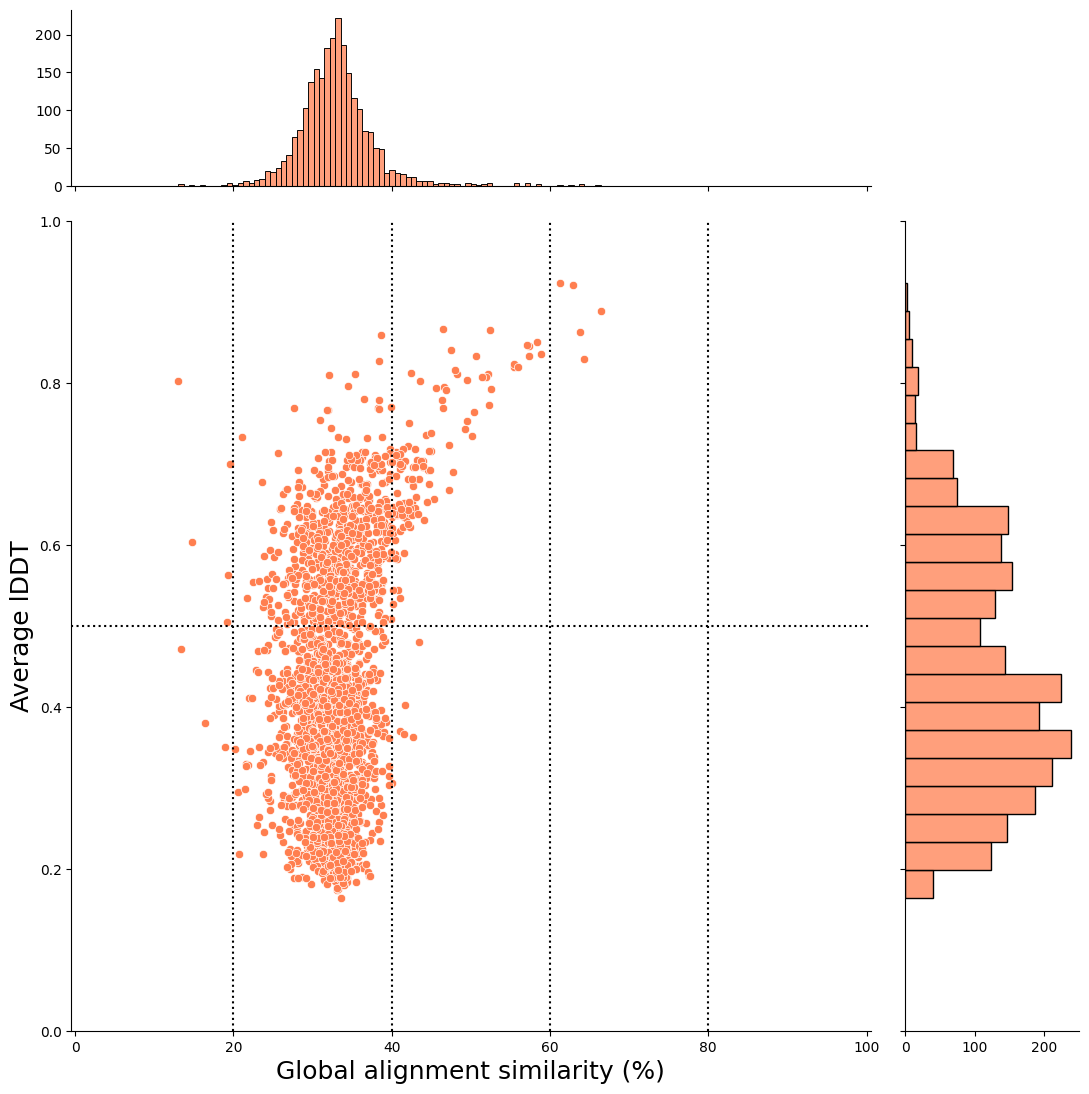

In [11]:
foldseek_filter_viz2 = join_foldseek.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz2,
    x="Similarity_percent_needle",
    y="lddt",
    color="coral",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100.5)
plt.ylim(0,1)
plt.xlabel("Global alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_needle_lddt_all.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## Create Scatter Plot for all hits (x-axis: Similarity_percent_water) Local Alignment

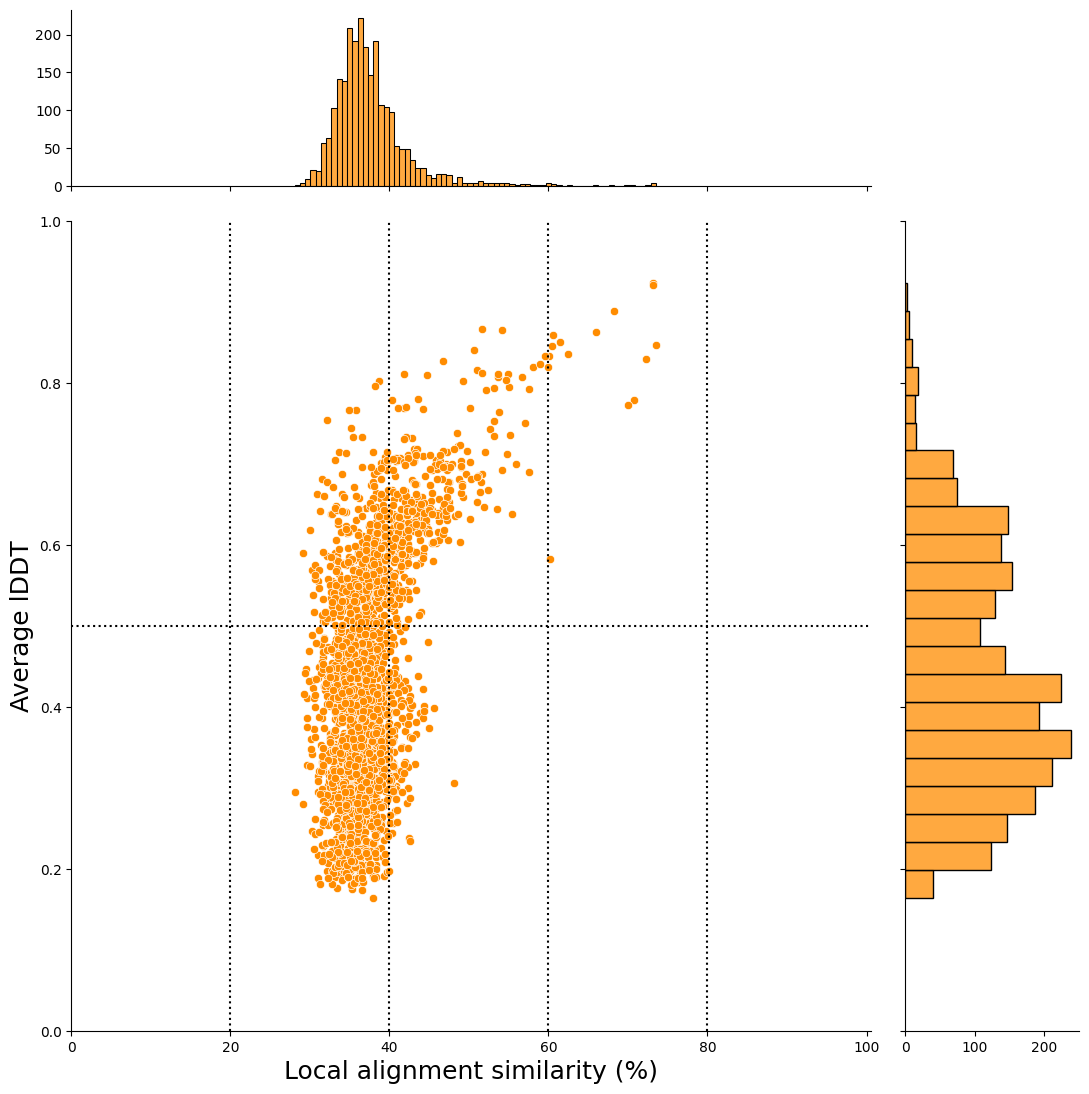

In [12]:
foldseek_filter_viz2 = join_foldseek.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz2,
    x="Similarity_percent_water", # local alignment similarity
    y="lddt",
    color="darkorange",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(0,100.5)
plt.ylim(0,1)
plt.xlabel("Local alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_water_lddt_all.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (6) Counting foldseek hits in Gene level

In [13]:
all_gene_list = pl.read_csv(
    query_gene_list_tsv_path,
    separator='\t'
).select(
    "From"
).unique()

hit_count = all_gene_list.join(
    join_foldseek,
    on="From",
    how="left",
    coalesce=True
).group_by("From", maintain_order=True).agg(
    (pl.col("foldseek hit").count().alias("target hit count (gene level vs uniprot accession)")),
    (pl.col("foldseek hit").is_null().all().alias("foldseek no hit"))
).sort(
    ["target hit count (gene level vs uniprot accession)"], descending=True
)

hit_count.write_csv(
    "foldseek_result_gene_level_hit_count_all.tsv",
    separator='\t'
)

display(hit_count)

From,target hit count (gene level vs uniprot accession),foldseek no hit
str,u32,bool
"""GLYMA_10G064500""",271,false
"""GLYMA_02G219300""",212,false
"""GLYMA_02G009200""",206,false
"""GLYMA_09G091900""",146,false
"""GLYMA_04G069400""",101,false
…,…,…
"""GLYMA_02G026700""",0,true
"""GLYMA_11G254600""",0,true
"""GLYMA_06G189800""",0,true


&nbsp;

&nbsp;

&nbsp;

# Caution:

- The filtering steps that are executed below can be changed freely.

&nbsp;

## (7) Filtering Condition1

- alignment coverage `>= 0.5`

In [14]:
condition1 = join_foldseek.filter(
        (pl.col("qcov") >= 0.5) &
        (pl.col("tcov") >= 0.5)
    ).sort(
        by=["From", "foldseek hit", "UniProt Accession"], # sort by From, foldseek hit, UniProt Accession
        descending=[False, False, False]
    )

condition1_rm = condition1.filter(
        (pl.col("qcov") < 0.5) |
        (pl.col("tcov") < 0.5)
    )

print(condition1.group_by(["From"], maintain_order=True).n_unique())
display(condition1)

shape: (57, 52)
┌────────────┬────────────┬────────────┬────────┬───┬────────────┬────────────┬───────────┬────────┐
│ From       ┆ UniProt    ┆ foldseek   ┆ evalue ┆ … ┆ Score_need ┆ Gap_penalt ┆ Extend_pe ┆ Matrix │
│ ---        ┆ Accession  ┆ hit        ┆ ---    ┆   ┆ le         ┆ y          ┆ nalty     ┆ ---    │
│ str        ┆ ---        ┆ ---        ┆ u32    ┆   ┆ ---        ┆ ---        ┆ ---       ┆ u32    │
│            ┆ u32        ┆ u32        ┆        ┆   ┆ u32        ┆ u32        ┆ u32       ┆        │
╞════════════╪════════════╪════════════╪════════╪═══╪════════════╪════════════╪═══════════╪════════╡
│ GLYMA_01G0 ┆ 1          ┆ 16         ┆ 16     ┆ … ┆ 15         ┆ 1          ┆ 1         ┆ 1      │
│ 80400      ┆            ┆            ┆        ┆   ┆            ┆            ┆           ┆        │
│ GLYMA_02G0 ┆ 1          ┆ 206        ┆ 192    ┆ … ┆ 184        ┆ 1          ┆ 1         ┆ 1      │
│ 09200      ┆            ┆            ┆        ┆   ┆            ┆         

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""GLYMA_01G080400""","""I1J6J3""","""A0A1B0GUV8""",0.2641,0.057,15,2.7,0.027,5,61,204,204,35,148,181,182,0.706,0.63,0.3298,0.2687,0.2962,0.4266,4.62,"""GGK-GMSGFH-DVEL-KVRDYELDQYGVVN…","""AQKVEGRWLTLQLAANHAD-----------…",71,"""0.371,0.520,0.471,0.500,0.457,…",173,268,"""34/173""","""34/268""",19.7,12.7,33.5,21.6,"""59/173""","""151/268""",34.1,56.3,16.67,16.67,29.82,29.06,28.43,28.43,50.88,49.57,117.5,114.5,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_01G080400""","""I1J6J3""","""P0DMR3""",0.2589,0.057,22,2.1,0.021,6,11,186,204,17,200,200,281,0.863,0.92,0.2925,0.275,0.2787,0.3099,4.763,"""LPSP--------------------------…","""RVPFSGLKEEEEEDGEDDEEEEEEGFFQKV…",73,"""0.312,0.344,0.344,0.312,0.074,…",164,270,"""30/164""","""35/270""",18.3,13.0,37.8,24.1,"""38/164""","""136/270""",23.2,50.4,14.71,17.16,23.81,26.12,30.39,31.86,49.21,48.51,123.5,121.0,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_01G080400""","""I1J6J3""","""P41222""",0.2362,0.045,11,3.4,0.034,6,62,184,204,31,156,190,175,0.603,0.663,0.2729,0.2472,0.2616,0.3635,5.054,"""GKGMSG----------------FHDVELKV…","""QPNFQQDKFLGRWFSAGLASNS--------…",68,"""0.204,0.357,0.154,0.218,0.250,…",229,243,"""43/229""","""43/243""",18.8,17.7,34.5,32.5,"""78/229""","""92/243""",34.1,37.9,21.08,21.08,28.48,28.48,38.73,38.73,52.32,52.32,141.5,141.5,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_01G080400""","""I1J6J3""","""P86397""",0.5065,0.353,7,5.2,0.052,8,62,190,204,36,167,168,153,0.632,0.786,0.6484,0.4741,0.5672,0.7269,2.534,"""GKGMSGFHDVELKVRD-YEL---------D…","""IKVG-DRAELRRAFTQTDVATFSELTGDVN…",100,"""0.289,0.271,0.426,0.516,0.363,…",213,227,"""37/213""","""37/227""",17.4,16.3,37.6,35.2,"""68/213""","""82/227""",31.9,36.1,18.14,18.14,25.52,25.52,39.22,39.22,55.17,55.17,147.5,147.5,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_01G080400""","""I1J6J3""","""Q15005""",0.2112,0.034,21,2.7,0.027,8,9,202,204,16,196,226,289,0.951,0.801,0.3322,0.2419,0.2242,0.2631,6.298,"""MSLPSPLYLNTTS---FRLTRQSPFPFPRR…","""GCSGAGGASNCGTGSG--------------…",78,"""0.438,0.594,0.719,0.812,0.969,…",221,277,"""42/221""","""44/277""",19.0,15.9,37.6,30.3,"""71/221""","""124/277""",32.1,44.8,18.58,19.47,28.0,28.76,36.73,37.17,55.33,54.9,148.0,140.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GLYMA_20G175900""","""I1NHA9""","""Q8N0W5""",0.2183,0.045,43,1.4,0.014,4,3,222,235,51,215,287,283,0.936,0.575,0.3584,0.2559,0.2209,0.3206,6.324,"""S-LKF-A-S--LT--LPPCSR-RSGMLGKR…","""SKNLWEQICKEYEAEQPPFPEGYKVKQEPV…",98,"""0.292,0.321,0.562,0.688,0.469,…",285,346,"""50/285""","""50/346""",17.5,14.5,34.0,28.0,"""110/285""","""170/346""",38.6,49.1,17.42,17.42,28.57,28.41,33.8,33.8,55.43,55.11,196.0,195.0,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_20G225700""","""C6SW21""","""P0DW13""",0.1905,0.024,13,1.2,0.012,3,15,181,195,45,198,198,249,0.856,0.778,0.489,0.2119,0.2095,0.2506,6.074,"""S-SS--------------------------…","""EL-RSEDVMDLTEGDSEASASAPPAAKRRK…",69,"""0.125,0.125,0.600,0.661,0.650,…",208,247,"""43/208""","""43/247""",20.7,17.4,33.7,29.1,"""74/208""","""101/247""",35.6,40.9,21.72,21.72,32.09,29.45,35.35,36.36,52.24,49.32,164.

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (8) Filtering Condition2

- If there are hits with the same target for the same gene-derived UniProt ID, the one with the highest qcov is selected, and if the qcov is the same, the one with the highest lDDT is selected.
- **Note that in this study, we leave the states with the same foldseek hit even if the rice genes are different.**

In [15]:
condition2 = condition1.sort(
    by=["qcov", "lddt"],
    descending=[True, True]
).group_by(
    ["From", "foldseek hit"],
    maintain_order=True
).agg(
    pl.all().first()
).sort(
    by=["From", "UniProt Accession", "foldseek hit"],
    descending=[False, False, False]
).select(
    "From",
    "UniProt Accession",
    "foldseek hit",
    "evalue",
    "prob",
    "gapopen",
    "pident",
    "fident",
    "nident",
    "qstart",
    "qend",
    "qlen",
    "tstart",
    "tend",
    "tlen",
    "alnlen",
    "qcov",
    "tcov",
    "lddt",
    "qtmscore",
    "ttmscore",
    "alntmscore",
    "rmsd",
    "mismatch",
    "Align_Length_water",
    "Align_Length_needle",
    "Identity_water",
    "Identity_needle",
    "Identity_percent_water",
    "Identity_percent_needle",
    "Similarity_percent_water",
    "Similarity_percent_needle",
    "Shortest_Identity_water",
    "Shortest_Identity_needle",
    "Longest_Identity_water",
    "Longest_Identity_needle",
    "Shortest_Similarity_water",
    "Shortest_Similarity_needle",
    "Longest_Similarity_water",
    "Longest_Similarity_needle",
    "Gaps_water",
    "Gaps_percent_water",
    "Gaps_needle",
    "Gaps_percent_needle",
    "Score_water",
    "Score_needle",
    "Gap_penalty",
    "Extend_penalty",
    "Matrix"
)

display(condition2)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,mismatch,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,str
"""GLYMA_01G080400""","""I1J6J3""","""A0A1B0GUV8""",0.2641,0.057,15,2.7,0.027,5,61,204,204,35,148,181,182,0.706,0.63,0.3298,0.2687,0.2962,0.4266,4.62,71,173,268,"""34/173""","""34/268""",19.7,12.7,33.5,21.6,16.67,16.67,29.82,29.06,28.43,28.43,50.88,49.57,"""59/173""",34.1,"""151/268""",56.3,117.5,114.5,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_01G080400""","""I1J6J3""","""P0DMR3""",0.2589,0.057,22,2.1,0.021,6,11,186,204,17,200,200,281,0.863,0.92,0.2925,0.275,0.2787,0.3099,4.763,73,164,270,"""30/164""","""35/270""",18.3,13.0,37.8,24.1,14.71,17.16,23.81,26.12,30.39,31.86,49.21,48.51,"""38/164""",23.2,"""136/270""",50.4,123.5,121.0,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_01G080400""","""I1J6J3""","""P41222""",0.2362,0.045,11,3.4,0.034,6,62,184,204,31,156,190,175,0.603,0.663,0.2729,0.2472,0.2616,0.3635,5.054,68,229,243,"""43/229""","""43/243""",18.8,17.7,34.5,32.5,21.08,21.08,28.48,28.48,38.73,38.73,52.32,52.32,"""78/229""",34.1,"""92/243""",37.9,141.5,141.5,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_01G080400""","""I1J6J3""","""P86397""",0.5065,0.353,7,5.2,0.052,8,62,190,204,36,167,168,153,0.632,0.786,0.6484,0.4741,0.5672,0.7269,2.534,100,213,227,"""37/213""","""37/227""",17.4,16.3,37.6,35.2,18.14,18.14,25.52,25.52,39.22,39.22,55.17,55.17,"""68/213""",31.9,"""82/227""",36.1,147.5,147.5,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_01G080400""","""I1J6J3""","""Q15005""",0.2112,0.034,21,2.7,0.027,8,9,202,204,16,196,226,289,0.951,0.801,0.3322,0.2419,0.2242,0.2631,6.298,78,221,277,"""42/221""","""44/277""",19.0,15.9,37.6,30.3,18.58,19.47,28.0,28.76,36.73,37.17,55.33,54.9,"""71/221""",32.1,"""124/277""",44.8,148.0,140.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GLYMA_20G175900""","""I1NHA9""","""Q8N0W5""",0.2183,0.045,43,1.4,0.014,4,3,222,235,51,215,287,283,0.936,0.575,0.3584,0.2559,0.2209,0.3206,6.324,98,285,346,"""50/285""","""50/346""",17.5,14.5,34.0,28.0,17.42,17.42,28.57,28.41,33.8,33.8,55.43,55.11,"""110/285""",38.6,"""170/346""",49.1,196.0,195.0,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_20G225700""","""C6SW21""","""P0DW13""",0.1905,0.024,13,1.2,0.012,3,15,181,195,45,198,198,249,0.856,0.778,0.489,0.2119,0.2095,0.2506,6.074,69,208,247,"""43/208""","""43/247""",20.7,17.4,33.7,29.1,21.72,21.72,32.09,29.45,35.35,36.36,52.24,49.32,"""74/208""",35.6,"""101/247""",40.9,164.0,160.0,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_20G225700""","""C6SW21""","""P0DW14""",0.2137,0.034,17,2.0,0.02,5,13,182,195,43,198,198,249,0.872,0.788,0.4946,0.2359,0.2325,0.2736,5.974,72,208,247,"""43/208""","""43/247""",20.7,17.4,33.7,29.1,21.72,21.72,32.09,29.45,35.35,36.36,52.24,49.32,"""74/208""",35.6,"""101/247""",40.9,164.0,160.0,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (9) Filtering Condition3

- Select hits that can be converted to Ensembl gene id and HGNC Gene nomenclature with TogoID API
- https://togoid.dbcls.jp/

In [16]:
togoid_convert = pl.read_csv(
    togoid_convert_tsv_path,
    separator='\t'
).rename(
    {
        "uniprot_id" : "foldseek hit"
    }
).filter(
    pl.col("ensembl_gene_id").is_not_null() &
    pl.col("hgnc_symbol_id").is_not_null() # add HGNC Gene nomenclature information filtering condition
).sort(
    by=["foldseek hit"],
    descending=[False]
)

display(togoid_convert)

foldseek hit,ensembl_protein_id,ensembl_transcript_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id
str,str,str,str,i64,str
"""A0A087X1G2""","""ENSP00000484181""","""ENST00000620247""","""ENSG00000273513""",51245,"""TBC1D3K"""
"""A0A1B0GUS4""","""ENSP00000490834""","""ENST00000436446""","""ENSG00000236444""",13477,"""UBE2L5"""
"""A0A1B0GUS4""","""ENSP00000490225""","""ENST00000635918""","""ENSG00000236444""",13477,"""UBE2L5"""
"""A0A1B0GUS4""","""ENSP00000490931""","""ENST00000638137""","""ENSG00000236444""",13477,"""UBE2L5"""
"""A0A1W2PPF3""","""ENSP00000491301""","""ENST00000633875""","""ENSG00000282757""",33345,"""DUXB"""
…,…,…,…,…,…
"""Q9Y6S9""","""ENSP00000450660""","""ENST00000555009""","""ENSG00000198208""",20222,"""RPS6KL1"""
"""Q9Y6S9""","""ENSP00000452027""","""ENST00000555647""","""ENSG00000198208""",20222,"""RPS6KL1"""
"""Q9Y6S9""","""ENSP00000450567""","""ENST00000557413""","""ENSG00000198208""",20222,"""RPS6KL1"""


In [17]:
condition3 = condition2.join(
    togoid_convert,
    on="foldseek hit",
    how="left",
    coalesce=True
).drop(
    [
        "ensembl_transcript_id",
        "hgnc_id"
    ]
).filter( 
    pl.col("ensembl_gene_id").is_not_null() &
    pl.col("hgnc_symbol_id").is_not_null() # add HGNC Gene nomenclature information filtering condition
).select(
    [
        "From",
        "UniProt Accession",
        "foldseek hit",
        "ensembl_protein_id",
        "ensembl_gene_id",
        "hgnc_symbol_id",
        "evalue",
        "prob",
        "gapopen",
        "pident",
        "fident",
        "nident",
        "qstart",
        "qend",
        "qlen",
        "tstart",
        "tend",
        "tlen",
        "alnlen",
        "mismatch",
        "qcov",
        "tcov",
        "rmsd",
        "lddt",
        "qtmscore",
        "ttmscore",
        "alntmscore",
        "Align_Length_water",
        "Align_Length_needle",
        "Identity_water",
        "Identity_percent_water",
        "Identity_percent_needle",
        "Similarity_percent_water",
        "Similarity_percent_needle",
        "Shortest_Identity_water",
        "Shortest_Identity_needle",
        "Longest_Identity_water",
        "Longest_Identity_needle",
        "Shortest_Similarity_water",
        "Shortest_Similarity_needle",
        "Longest_Similarity_water",
        "Longest_Similarity_needle",
        "Gaps_water",
        "Gaps_percent_water",
        "Gaps_needle",
        "Gaps_percent_needle",
        "Score_water",
        "Score_needle",
        "Gap_penalty",
        "Extend_penalty",
        "Matrix"
    ]
).sort(
    by=["From", "foldseek hit", "UniProt Accession"], # sort by From, foldseek hit, UniProt Accession (change order)
    descending=[False, False, False]
)

condition3.write_csv(
    "foldseek_result_join_alignment_result_filter.tsv",
    separator='\t'
)

display(condition3)

From,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,Align_Length_water,Align_Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,str
"""GLYMA_01G080400""","""I1J6J3""","""P41222""","""ENSP00000360687""","""ENSG00000107317""","""PTGDS""",0.2362,0.045,11,3.4,0.034,6,62,184,204,31,156,190,175,68,0.603,0.663,5.054,0.2729,0.2472,0.2616,0.3635,229,243,"""43/229""",18.8,17.7,34.5,32.5,21.08,21.08,28.48,28.48,38.73,38.73,52.32,52.32,"""78/229""",34.1,"""92/243""",37.9,141.5,141.5,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_01G080400""","""I1J6J3""","""P86397""","""ENSP00000484277""","""ENSG00000255154""","""HTD2""",0.5065,0.353,7,5.2,0.052,8,62,190,204,36,167,168,153,100,0.632,0.786,2.534,0.6484,0.4741,0.5672,0.7269,213,227,"""37/213""",17.4,16.3,37.6,35.2,18.14,18.14,25.52,25.52,39.22,39.22,55.17,55.17,"""68/213""",31.9,"""82/227""",36.1,147.5,147.5,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_01G080400""","""I1J6J3""","""P86397""","""ENSP00000481593""","""ENSG00000255154""","""HTD2""",0.5065,0.353,7,5.2,0.052,8,62,190,204,36,167,168,153,100,0.632,0.786,2.534,0.6484,0.4741,0.5672,0.7269,213,227,"""37/213""",17.4,16.3,37.6,35.2,18.14,18.14,25.52,25.52,39.22,39.22,55.17,55.17,"""68/213""",31.9,"""82/227""",36.1,147.5,147.5,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_01G080400""","""I1J6J3""","""P86397""","""ENSP00000482940""","""ENSG00000255154""","""HTD2""",0.5065,0.353,7,5.2,0.052,8,62,190,204,36,167,168,153,100,0.632,0.786,2.534,0.6484,0.4741,0.5672,0.7269,213,227,"""37/213""",17.4,16.3,37.6,35.2,18.14,18.14,25.52,25.52,39.22,39.22,55.17,55.17,"""68/213""",31.9,"""82/227""",36.1,147.5,147.5,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_01G080400""","""I1J6J3""","""Q15005""","""ENSP00000263672""","""ENSG00000118363""","""SPCS2""",0.2112,0.034,21,2.7,0.027,8,9,202,204,16,196,226,289,78,0.951,0.801,6.298,0.3322,0.2419,0.2242,0.2631,221,277,"""42/221""",19.0,15.9,37.6,30.3,18.58,19.47,28.0,28.76,36.73,37.17,55.33,54.9,"""71/221""",32.1,"""124/277""",44.8,148.0,140.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GLYMA_20G175900""","""I1NHA9""","""Q8N0W5""","""ENSP00000511791""","""ENSG00000174628""","""IQCK""",0.2183,0.045,43,1.4,0.014,4,3,222,235,51,215,287,283,98,0.936,0.575,6.324,0.3584,0.2559,0.2209,0.3206,285,346,"""50/285""",17.5,14.5,34.0,28.0,17.42,17.42,28.57,28.41,33.8,33.8,55.43,55.11,"""110/285""",38.6,"""170/346""",49.1,196.0,195.0,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_20G225700""","""C6SW21""","""P0DW13""","""ENSP00000491174""","""ENSG00000283967""","""TAF11L8""",0.1905,0.024,13,1.2,0.012,3,15,181,195,45,198,198,249,69,0.856,0.778,6.074,0.489,0.2119,0.2095,0.2506,208,247,"""43/208""",20.7,17.4,33.7,29.1,21.72,21.72,32.09,29.45,35.35,36.36,52.24,49.32,"""74/208""",35.6,"""101/247""",40.9,164.0,160.0,10.0,0.5,"""EBLOSUM30"""
"""GLYMA_20G225700""","""C6SW21""","""P0DW14""","""ENSP00000491873""","""ENSG00000284356""","""TAF11L10""",0.2137,0.034,17,2.0,0.02,5,13,182,195,43,198,198,249,72,0.872,0.788,5.974,0.4946,0.2359,0.2325,0.2736,208,247,"""43/208""",20.7,17.4,33.7,29.1,21.72,21.72,32.09,29.45,35.35,36.36,52.24,49.32,"""74/208""",35.6,"""101/247""",40.9,164.0,160.0,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;


In [18]:
foldseek_filter_viz = condition3.select(
    "From",
    "UniProt Accession",
    "foldseek hit",
    "qcov",
    "tcov",
    "rmsd",
    "lddt",
    "Identity_percent_needle",
    "Identity_percent_water",
    "Similarity_percent_needle",
    "Similarity_percent_water"
).unique(
    subset=["From", "UniProt Accession", "foldseek hit"]
).sort(
    by=["From"],
    descending=[False]
)

display(foldseek_filter_viz)

From,UniProt Accession,foldseek hit,qcov,tcov,rmsd,lddt,Identity_percent_needle,Identity_percent_water,Similarity_percent_needle,Similarity_percent_water
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""GLYMA_01G080400""","""I1J6J3""","""Q9Y3B1""",0.691,0.789,6.722,0.3393,20.0,21.2,37.4,38.3
"""GLYMA_01G080400""","""I1J6J3""","""Q9H8M1""",0.922,0.958,6.069,0.3371,17.5,18.4,33.1,34.7
"""GLYMA_01G080400""","""I1J6J3""","""Q7Z2X4""",0.711,0.8,4.148,0.3531,15.0,16.8,28.8,31.4
"""GLYMA_01G080400""","""I1J6J3""","""Q96MF6""",0.701,0.66,6.031,0.3384,14.8,16.1,35.1,37.5
"""GLYMA_01G080400""","""I1J6J3""","""Q9NQM4""",0.858,0.565,5.565,0.3182,14.8,19.8,36.9,41.9
…,…,…,…,…,…,…,…,…,…,…
"""GLYMA_20G175900""","""I1NHA9""","""Q8IU54""",0.511,0.74,6.13,0.2937,19.9,21.7,31.7,34.1
"""GLYMA_20G225700""","""C6SW21""","""P0DW14""",0.872,0.788,5.974,0.4946,17.4,20.7,29.1,33.7
"""GLYMA_20G225700""","""C6SW21""","""P56915""",0.979,0.735,5.357,0.5541,14.1,21.3,22.5,38.1


<Figure size 4000x4000 with 0 Axes>

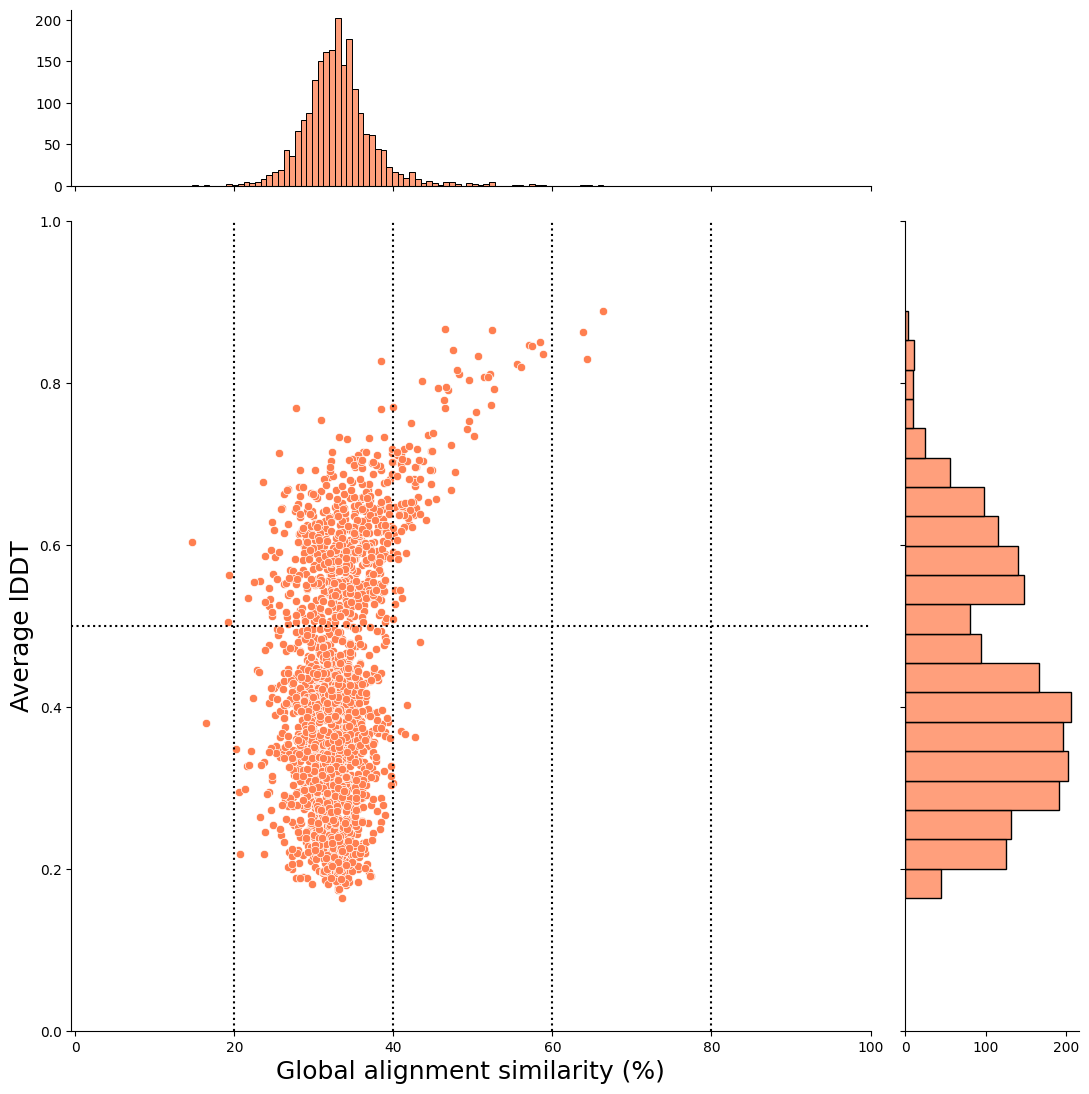

In [19]:
foldseek_filter_viz_pd = foldseek_filter_viz.to_pandas()

plt.figure(figsize=(8, 8), dpi=500)

sns.jointplot(
    data=foldseek_filter_viz_pd,
    x="Similarity_percent_needle",
    y="lddt",
    color="coral",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100)
plt.ylim(0,1)
plt.xlabel("Global alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_needle_lddt_filter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 4000x4000 with 0 Axes>

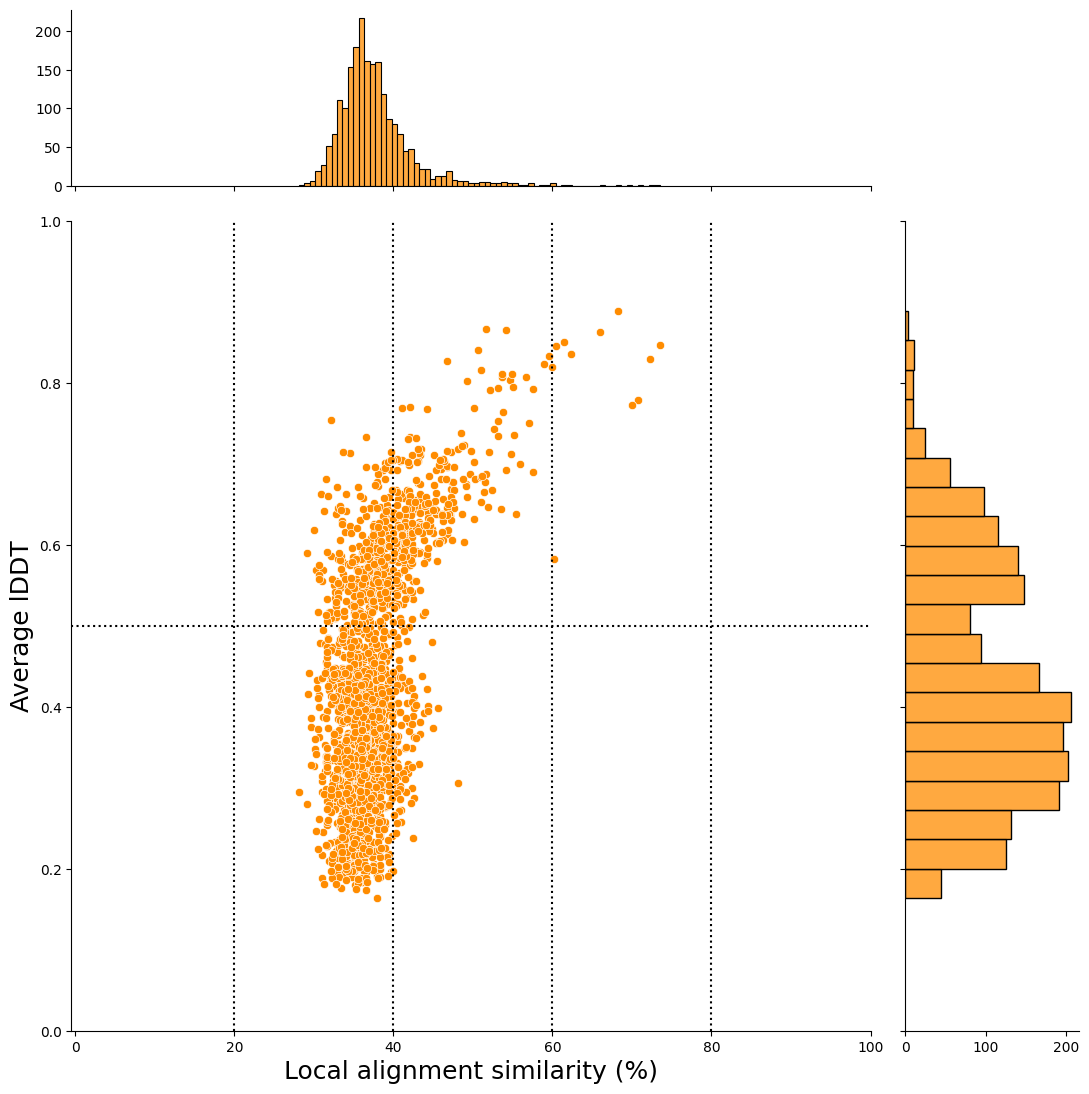

In [20]:
foldseek_filter_viz_pd = foldseek_filter_viz.to_pandas()

plt.figure(figsize=(8, 8), dpi=500)

sns.jointplot(
    data=foldseek_filter_viz_pd,
    x="Similarity_percent_water",
    y="lddt",
    color="darkorange",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100)
plt.ylim(0,1)
plt.xlabel("Local alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_water_lddt_filter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;
